# Neural Collaborative Filtering — Demo

End-to-end walkthrough of training and evaluating the three NCF models
(GMF, MLP, NeuMF) from He et al. (2017) on the MovieLens 1M dataset.

This notebook covers:

1. Data exploration
2. Training NeuMF on a small sample
3. Evaluating with HR@10 and NDCG@10
4. Visualizing training curves
5. Inspecting recommendations for individual users

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from Dataset import Dataset
from evaluate import evaluate_model
import NeuMF
from utils import get_optimizer_by_name, get_train_instances

## Data Exploration

We use the MovieLens 1M dataset, preprocessed into the NCF format:
one held-out positive per user in the test set, paired with 99 sampled negatives.

In [3]:
DATASET = 'ml-1m'
DATA_PATH = f'Data/{DATASET}'

dataset = Dataset(DATA_PATH)
train = dataset.train_matrix
num_users, num_items = dataset.num_users, dataset.num_items

print(f'Users:                 {num_users:,}')
print(f'Items:                 {num_items:,}')
print(f'Training interactions: {train.nnz:,}')
print(f'Test users:            {len(dataset.test_ratings):,}')
print(f'Sparsity:              {1 - train.nnz / (num_users * num_items):.4%}')

Users:                 6,040
Items:                 3,706
Training interactions: 994,169
Test users:            6,040
Sparsity:              95.5586%


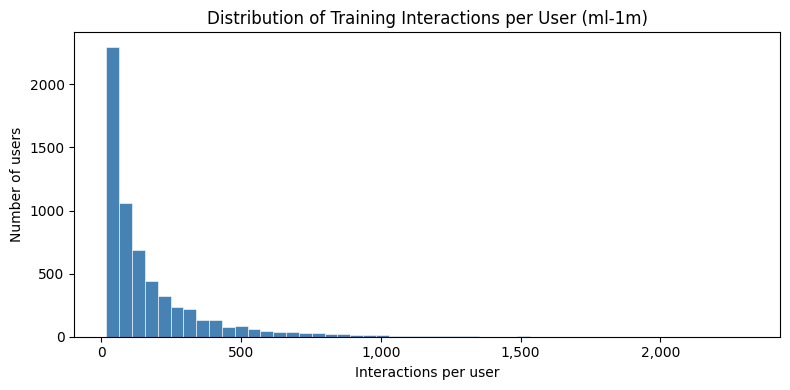

Median interactions per user: 95
Mean:   164.6
Max:    2313
Min:    19


In [4]:
train_df = pd.DataFrame(
    [(u, i) for (u, i) in train.keys()],
    columns=['user', 'item']
)
interactions_per_user = train_df.groupby('user').size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(interactions_per_user, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Interactions per user')
ax.set_ylabel('Number of users')
ax.set_title('Distribution of Training Interactions per User (ml-1m)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f'Median interactions per user: {interactions_per_user.median():.0f}')
print(f'Mean:   {interactions_per_user.mean():.1f}')
print(f'Max:    {interactions_per_user.max()}')
print(f'Min:    {interactions_per_user.min()}')

## Training

We train NeuMF on a 500-user sample of the dataset for speed.
To train on the full dataset, change `DATASET` below to `'ml-1m'`.

NeuMF combines two pathways:
- **GMF branch**: element-wise product of user and item embeddings (generalizes MF)
- **MLP branch**: concatenated embeddings passed through fully-connected layers

The two outputs are concatenated and passed to a final sigmoid prediction layer.

In [7]:
# To train on the full dataset, change this to 'ml-1m'
TRAIN_DATASET = 'sample-ml-1m'
TRAIN_PATH = f'Data/sample-ml-1m/{TRAIN_DATASET}'

# Model hyperparameters
MF_DIM = 8
LAYERS = [64, 32, 16, 8]
REG_LAYERS = [0, 0, 0, 0]
REG_MF = 0
NUM_NEG = 4
EPOCHS = 20
BATCH_SIZE = 256
LEARNING_RATE = 0.001
TOP_K = 10

In [8]:
train_dataset = Dataset(TRAIN_PATH)
train_matrix = train_dataset.train_matrix
test_ratings = train_dataset.test_ratings
test_negatives = train_dataset.test_negatives
n_users, n_items = train_dataset.num_users, train_dataset.num_items

model = NeuMF.get_model(n_users, n_items, MF_DIM, LAYERS, REG_LAYERS, REG_MF)
optimizer = get_optimizer_by_name('adam', learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='binary_crossentropy')

history = {'hr': [], 'ndcg': [], 'loss': []}

# Evaluate before any training
hits, ndcgs = evaluate_model(model, test_ratings, test_negatives, TOP_K)
history['hr'].append(np.mean(hits))
history['ndcg'].append(np.mean(ndcgs))
history['loss'].append(None)
print(f'Epoch  0 | HR@{TOP_K}: {history["hr"][-1]:.4f}  NDCG@{TOP_K}: {history["ndcg"][-1]:.4f}')

for epoch in range(1, EPOCHS + 1):
    user_input, item_input, labels = get_train_instances(
        train_matrix, n_items, NUM_NEG
    )
    hist = model.fit(
        [np.array(user_input), np.array(item_input)],
        np.array(labels),
        batch_size=BATCH_SIZE, epochs=1, shuffle=True, verbose=0,
    )
    loss = hist.history['loss'][0]

    hits, ndcgs = evaluate_model(model, test_ratings, test_negatives, TOP_K)
    hr, ndcg = np.mean(hits), np.mean(ndcgs)
    history['hr'].append(hr)
    history['ndcg'].append(ndcg)
    history['loss'].append(loss)
    print(f'Epoch {epoch:2d} | HR@{TOP_K}: {hr:.4f}  NDCG@{TOP_K}: {ndcg:.4f}  loss: {loss:.4f}')

best_epoch = int(np.argmax(history['hr']))
print(f'\nBest HR@{TOP_K}: {max(history["hr"]):.4f} at epoch {best_epoch}')
print(f'NDCG@{TOP_K} at best epoch: {history["ndcg"][best_epoch]:.4f}')

Epoch  0 | HR@10: 0.1020  NDCG@10: 0.0490
Epoch  1 | HR@10: 0.4620  NDCG@10: 0.2554  loss: 0.3955
Epoch  2 | HR@10: 0.4860  NDCG@10: 0.2715  loss: 0.3386
Epoch  3 | HR@10: 0.5180  NDCG@10: 0.2895  loss: 0.3121
Epoch  4 | HR@10: 0.5440  NDCG@10: 0.3016  loss: 0.2940
Epoch  5 | HR@10: 0.5640  NDCG@10: 0.3089  loss: 0.2802
Epoch  6 | HR@10: 0.5840  NDCG@10: 0.3204  loss: 0.2689
Epoch  7 | HR@10: 0.6020  NDCG@10: 0.3287  loss: 0.2599
Epoch  8 | HR@10: 0.5980  NDCG@10: 0.3353  loss: 0.2530
Epoch  9 | HR@10: 0.6040  NDCG@10: 0.3369  loss: 0.2468
Epoch 10 | HR@10: 0.6060  NDCG@10: 0.3361  loss: 0.2409
Epoch 11 | HR@10: 0.6140  NDCG@10: 0.3401  loss: 0.2358
Epoch 12 | HR@10: 0.6080  NDCG@10: 0.3430  loss: 0.2299
Epoch 13 | HR@10: 0.6060  NDCG@10: 0.3471  loss: 0.2244
Epoch 14 | HR@10: 0.6140  NDCG@10: 0.3456  loss: 0.2193
Epoch 15 | HR@10: 0.5920  NDCG@10: 0.3407  loss: 0.2145
Epoch 16 | HR@10: 0.6040  NDCG@10: 0.3379  loss: 0.2092
Epoch 17 | HR@10: 0.5920  NDCG@10: 0.3412  loss: 0.2036
Epoch 

## Training Curves

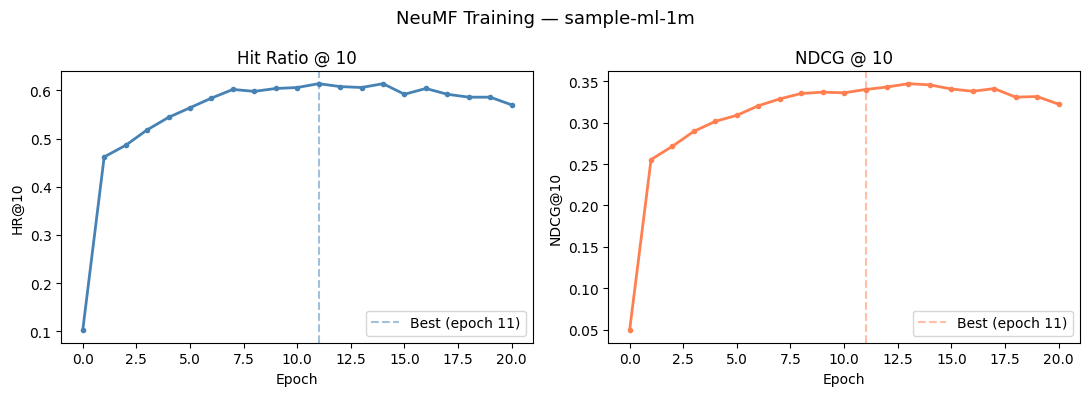

In [9]:
epochs_axis = list(range(len(history['hr'])))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs_axis, history['hr'], color='steelblue', linewidth=2, marker='o', markersize=3)
axes[0].axvline(best_epoch, color='steelblue', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel(f'HR@{TOP_K}')
axes[0].set_title(f'Hit Ratio @ {TOP_K}')
axes[0].legend()

axes[1].plot(epochs_axis, history['ndcg'], color='coral', linewidth=2, marker='o', markersize=3)
axes[1].axvline(best_epoch, color='coral', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel(f'NDCG@{TOP_K}')
axes[1].set_title(f'NDCG @ {TOP_K}')
axes[1].legend()

plt.suptitle(f'NeuMF Training — {TRAIN_DATASET}', fontsize=13)
plt.tight_layout()
plt.show()

## Inspecting Recommendations

For a handful of users, we show the ground-truth test item alongside
the model's top-K recommendations from the 99-negative evaluation pool.

A ✓ means the model ranked the held-out item in its top 10.

In [10]:
NUM_DISPLAY_USERS = 5
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(test_ratings), size=NUM_DISPLAY_USERS, replace=False)

for idx in sorted(sample_indices):
    u = test_ratings[idx][0]
    gt_item = test_ratings[idx][1]
    candidates = test_negatives[idx] + [gt_item]

    users_arr = np.full(len(candidates), u, dtype='int32')
    items_arr = np.array(candidates, dtype='int32')
    preds = model.predict([users_arr, items_arr], verbose=0).flatten()

    scores = dict(zip(candidates, preds))
    top_k = sorted(scores, key=scores.get, reverse=True)[:TOP_K]

    hit = '✓' if gt_item in top_k else '✗'
    rank = top_k.index(gt_item) + 1 if gt_item in top_k else None
    rank_str = f'rank {rank}' if rank else 'not in top 10'

    print(f'User {u:4d} | ground truth: item {gt_item:4d} | {hit} {rank_str}')
    print(f'          top-{TOP_K}: {top_k}')
    print()

User   44 | ground truth: item 1772 | ✓ rank 3
          top-10: [183, 419, 1772, 675, 405, 402, 617, 498, 791, 579]

User  216 | ground truth: item  534 | ✗ not in top 10
          top-10: [22, 839, 741, 369, 17, 1263, 275, 183, 600, 993]

User  219 | ground truth: item  979 | ✓ rank 1
          top-10: [979, 1276, 662, 238, 255, 871, 629, 405, 445, 155]

User  325 | ground truth: item  757 | ✗ not in top 10
          top-10: [771, 342, 1001, 1295, 722, 110, 1347, 570, 576, 319]

User  384 | ground truth: item 1613 | ✓ rank 4
          top-10: [1112, 406, 669, 1613, 860, 630, 486, 202, 321, 464]

